In [2]:
import json
import os
import torch
# Load the configuration from the JSON file
with open(r'C:\Users\Rishabh\Documents\3d-hcct\config.json', 'r') as f:
    config = json.load(f)

In [3]:
from model import ViTForClassfication

# Initialize the model with the loaded configuration
model = ViTForClassfication(config=config)

In [4]:
os.listdir(r'C:\Users\Rishabh')

['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.config',
 '.continuum',
 '.deepface',
 '.docker',
 '.gitconfig',
 '.ipython',
 '.jupyter',
 '.keras',
 '.lesshst',
 '.matplotlib',
 '.pyment',
 '.ssh',
 '.vscode',
 '.yarnrc',
 '3D Objects',
 'anaconda3',
 'anaconda_projects',
 'ansel',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'HCCT_checkpoint_withoutT.pth.tar',
 'HCCT_checkpoint_withTransformation.pth.tar',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'nilearn_data',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'Postman',
 'PrintHood',
 'Recent',
 'Saved Games',
 

In [5]:
from collections import OrderedDict
# checkpoint_path = r'C:\Users\Rishabh\training_output_metricsHCCT_best_model.pth.tar'
checkpoint_path = r'C:\Users\Rishabh\HCCT_checkpoint_withTransformation.pth.tar'
# checkpoint_path = r'C:\Users\Rishabh\HCCT_checkpoint_withoutT.pth.tar'

checkpoint = torch.load(checkpoint_path, map_location='cpu')
state_dict = checkpoint['state_dict']

# Remove 'module.' prefix if it exists
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace('module.', '')  # strip the prefix
    new_state_dict[name] = v

model.load_state_dict(new_state_dict, strict=True)  # strict ensures all match


<All keys matched successfully>

In [6]:
import nibabel as nib
import pandas as pd
DataFolder = r'C:\Users\Rishabh\Documents\TrimeseData'
CSVPath = r'C:\Users\Rishabh\Documents\TransBTS\IXI.xlsx'
Files = os.listdir(DataFolder)
ixi_ids = [int(f[3:6]) for f in Files]
print(ixi_ids)  # [2, 19, 20]

[2, 2, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 19, 19, 20, 20, 21, 21, 22, 22, 23, 23, 24, 24, 25, 25, 26, 26, 27, 27, 28, 28, 29, 29, 30, 30, 31, 31, 33, 33, 34, 34, 35, 35, 36, 36, 37, 37, 38, 38, 39, 39, 40, 40, 41, 41, 42, 42, 43, 43, 44, 44, 45, 45, 46, 46, 48, 48, 49, 49, 50, 50, 51, 51, 52, 52, 53, 53, 54, 54, 55, 55, 56, 56, 57, 57, 58, 58, 59, 59, 60, 60, 61, 61, 62, 62, 63, 63, 64, 64, 65, 65, 66, 66, 67, 67, 68, 68, 69, 69, 70, 70, 71, 71, 72, 72, 73, 73, 74, 74, 75, 75, 76, 76, 77, 77, 78, 78, 79, 79, 80, 80, 81, 81, 83, 83, 84, 84, 85, 85, 86, 86, 87, 87, 88, 88, 89, 89, 90, 90, 91, 91, 92, 92, 93, 93, 94, 94, 95, 95, 96, 96, 97, 97, 98, 98, 99, 99, 100, 100, 101]


In [7]:
df = pd.read_excel(CSVPath)

In [8]:

def white0(image, threshold=0):
    """
    Standardize voxels with value > threshold

    Args:
        image: Input image
        threshold: Threshold value

    Returns:
        Standardized image
    """
    image = image.astype(np.float32)
    mask = (image > threshold).astype(int)

    # Vectorized implementation to avoid unnecessary memory allocation
    image_h = image * mask

    # Calculate mean and std only for relevant voxels
    non_zero_voxels = np.sum(mask)
    if non_zero_voxels > 0:
        mean = np.sum(image_h) / non_zero_voxels

        # More memory efficient way to calculate std
        std_sum = np.sum((image_h - mean * mask) ** 2)
        std = np.sqrt(std_sum / non_zero_voxels)

        if std > 0:
            normalized = mask * (image - mean) / std
            # Use in-place operations to reduce memory usage
            image = normalized + image * (1 - mask)
            return image

    # Default case
    return np.zeros_like(image, dtype=np.float32)

In [9]:
import os, gc
import numpy as np
import nibabel as nib
import torch

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
model.to(device)
model.eval()  # deterministic dropout/BN

indx = 30
filename = Files[indx]

file_path = os.path.join(DataFolder, filename)
img = nib.load(file_path)
x_np = img.get_fdata(caching='unchanged').astype(np.float32)       # avoid float64 bloat

inputvolume = white0(x_np)
inputvolume = torch.from_numpy(inputvolume).unsqueeze(0).unsqueeze(0).to(device).float()
inputvolume = inputvolume.to(device).type(torch.FloatTensor)



with torch.no_grad():
    out,all_attention = model(inputvolume, output_attentions=True)
logits = out[0] if isinstance(out, (tuple, list)) else out
_id = int(filename[3:6])
AGE = df[df['IXI_ID']==_id]['AGE'].values[0]
Predicted_Age = logits.item()



In [10]:
Predicted_Age, AGE

(26.223201751708984, np.float64(30.417522245037645))

In [11]:
# len(all_attention), all_attention[0].shape
Attn = torch.stack(all_attention)
Attn = torch.mean(Attn, dim=0)
Attn = torch.mean(Attn, dim=0)
Attn = torch.mean(Attn, dim=0)
Attn.shape

torch.Size([513, 513])

In [12]:
import cv2
att_mat = Attn
residual_att = torch.eye(att_mat.size(1)).to(device="cpu")
aug_att_mat = att_mat + residual_att
aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)

# Recursively multiply the weight matrices
joint_attentions = torch.zeros(aug_att_mat.size()).to(device="cpu")
joint_attentions[0] = aug_att_mat[0]

for n in range(1, aug_att_mat.size(0)):
    joint_attentions[n] = torch.matmul(aug_att_mat[n], joint_attentions[n - 1])

# Attention from the output token to the input space.
v = joint_attentions[0,1:].to(device="cpu")
print(len(v))
mask = v.reshape(8, 8, 8).detach().numpy()

512


In [13]:
import numpy as np
from scipy.ndimage import zoom

# Suppose mask.shape = (depth, height, width)
zoom_factors = (91 / mask.shape[0],
                109 / mask.shape[1],
                91 / mask.shape[2])

mask = zoom(mask, zoom_factors, order=1)  # order=1 → bilinear

In [14]:
mask.shape

(91, 109, 91)

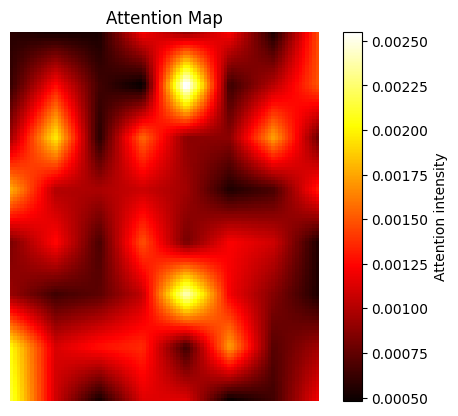

In [15]:
import matplotlib.pyplot as plt

plt.imshow(mask[34], cmap='hot')  # mask is your 2D NumPy array
plt.colorbar(label='Attention intensity')
plt.title('Attention Map')
plt.axis('off')
plt.show()

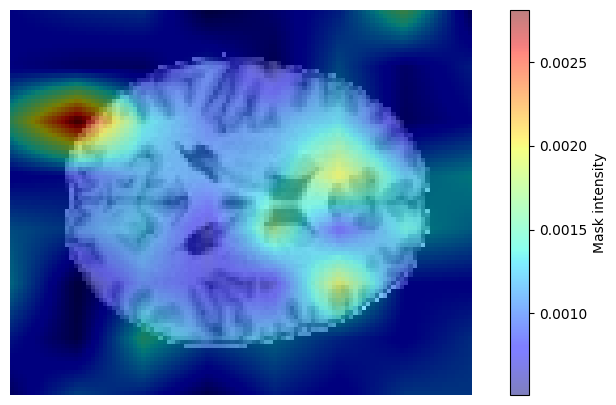

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Example: pick a middle slice along z-axis
slice_idx = x_np.shape[2] // 2  

img_slice = x_np[:, :, slice_idx]
mask_slice = mask[:, :, slice_idx]

plt.figure(figsize=(10,5))

# Show base image
plt.imshow(img_slice, cmap='gray')

# Overlay mask with transparency
plt.imshow(mask_slice, cmap='jet', alpha=0.5)  # alpha controls overlay strength
plt.colorbar(label="Mask intensity")
plt.axis("off")
plt.show()


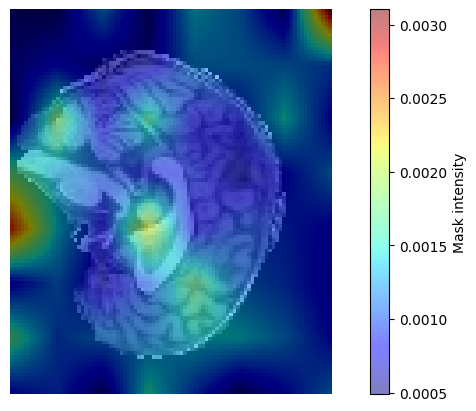

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Example: pick a middle slice along z-axis
slice_idx = x_np.shape[0] // 2  

img_slice = x_np[slice_idx, :, :]
mask_slice = mask[slice_idx, :, :]

plt.figure(figsize=(10,5))

# Show base image
plt.imshow(img_slice, cmap='gray')

# Overlay mask with transparency
plt.imshow(mask_slice, cmap='jet', alpha=0.5)  # alpha controls overlay strength
plt.colorbar(label="Mask intensity")
plt.axis("off")
plt.show()

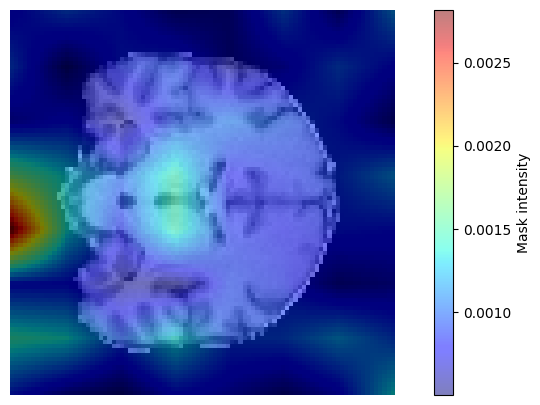

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Example: pick a middle slice along z-axis
slice_idx = x_np.shape[1] // 2  

img_slice = x_np[:, slice_idx, :]
mask_slice = mask[:,slice_idx, :]

plt.figure(figsize=(10,5))

# Show base image
plt.imshow(img_slice, cmap='gray')

# Overlay mask with transparency
plt.imshow(mask_slice, cmap='jet', alpha=0.5)  # alpha controls overlay strength
plt.colorbar(label="Mask intensity")
plt.axis("off")
plt.show()